# 📊 EDA — E-Commerce Product Categorisation

**Project:** `project_1` — MLOps course at USMBA  
**Dataset:** E-commerce product catalogue (`train.parquet.snappy`) from hw4  
**Task:** Multi-class text classification — predict `category_ind` from product metadata  

---

## Table of Contents
1. Setup & Data Loading
2. Dataset Overview (shape, dtypes)
3. Missing Value Analysis
4. Target Distribution (`category_ind`)
5. Text Feature Analysis (lengths, word counts)
6. Numerical Feature Distributions
7. Correlation Analysis
8. Class Imbalance Assessment
9. Key Findings & Recommendations

In [1]:
# ── 1. Setup ──────────────────────────────────────────────────────────────────
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Plot aesthetics
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# Paths — adjust if running from project root
DATA_DIR   = os.getenv('DATA_DIR', '../data')
TRAIN_FILE = os.path.join(DATA_DIR, 'train.parquet.snappy')
TEXT_COLS  = ['name', 'description', 'model', 'type_prefix', 'vendor', 'url']
TARGET_COL = 'category_ind'

print('Data path:', TRAIN_FILE)
print('File exists:', os.path.exists(TRAIN_FILE))

Data path: ../data/train.parquet.snappy
File exists: True


In [2]:
# ── 2. Load dataset ───────────────────────────────────────────────────────────
df = pd.read_parquet(TRAIN_FILE)
print(f'Shape: {df.shape[0]:,} rows  ×  {df.shape[1]} columns')
df.head(3)

Shape: 111,405 rows  ×  8 columns


,name,description,model,type_prefix,vendor,url,image_url,category_ind
0,Мягкая Кровать Орматек Como (Veda) 4 (Экокожа ...,Мягкая кровать с каретной пиковкой в изголовье...,Кровать Como (Veda) 4,Кровать,Орматек,https://ormatek.com/catalog/krovati/product/kr...,http://d.mradx.net//ecomimg/914/21/9a84a4b6cbb...,42
1,,,Kutay,,Unique е Luxury,https://www.spellsmell.ru/women/unique-e-luxur...,http://d.mradx.net//ecomimg/c86/20/4b6264724f8...,34
2,Стол для переговоров Мир 6,,,,"ООО ""Бэст-Мебель""",https://www.spb.bestmebelshop.ru/catalog/mebel...,http://d.mradx.net//ecomimg/dba/41/fc127f10db6...,48


In [3]:
# ── 2b. Column dtypes ─────────────────────────────────────────────────────────
print('\nColumn info:')
df.info(show_counts=True)


Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111405 entries, 0 to 111404
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   name          111405 non-null  object
 1   description   111405 non-null  object
 2   model         111405 non-null  object
 3   type_prefix   111405 non-null  object
 4   vendor        111405 non-null  object
 5   url           111405 non-null  object
 6   image_url     111405 non-null  object
 7   category_ind  111405 non-null  int64 
dtypes: int64(1), object(7)
memory usage: 6.8+ MB


In [4]:
print('Descriptive statistics (numeric columns):')
df.describe().T.style.background_gradient(axis=0, cmap='Blues')

Descriptive statistics (numeric columns):


,count,mean,std,min,25%,50%,75%,max
category_ind,111405.000000,66.634532,51.673172,0.000000,34.000000,48.000000,72.000000,222.000000


---
## 3. Missing Value Analysis

In [5]:
# ── 3a. Missing value counts ──────────────────────────────────────────────────
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'percent (%)': missing_pct})
missing_df = missing_df[missing_df['count'] > 0]

if missing_df.empty:
    print('✅  No missing values in any column.')
else:
    print(f'Columns with missing values ({len(missing_df)}):')
    display(missing_df)

✅  No missing values in any column.


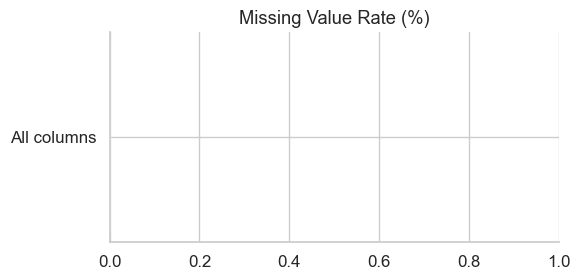

All columns are complete — no imputation needed.


In [6]:
# ── 3b. Missing value heatmap ─────────────────────────────────────────────────
if not missing_df.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    top_missing_cols = missing_df.index[:20].tolist()
    missing_matrix = df[top_missing_cols].isnull().astype(int)
    # Sample for speed
    sample = missing_matrix.sample(min(2000, len(missing_matrix)), random_state=42)
    sns.heatmap(sample.T, cbar=False, cmap='YlOrRd', ax=ax,
                yticklabels=top_missing_cols)
    ax.set_title('Missing Value Pattern (sample of 2000 rows)', fontsize=13)
    ax.set_xlabel('Row index (sampled)')
    plt.tight_layout()
    plt.show()
else:
    # Still create a summary bar even if no missing
    missing_all = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.barh(['All columns'], [0], color='green')
    ax.set_title('Missing Value Rate (%)')
    ax.set_xlim(0, 1)
    plt.tight_layout()
    plt.show()
    print('All columns are complete — no imputation needed.')

---
## 4. Target Distribution (`category_ind`)

In [7]:
# ── 4a. Class frequency table ─────────────────────────────────────────────────
y = df[TARGET_COL].astype(int)
vc = y.value_counts().sort_values(ascending=False)

print(f'Number of unique classes : {y.nunique()}')
print(f'Most common  class       : {vc.index[0]}  ({vc.iloc[0]:,} samples, {vc.iloc[0]/len(y)*100:.1f}%)')
print(f'Rarest class             : {vc.index[-1]}  ({vc.iloc[-1]:,} samples, {vc.iloc[-1]/len(y)*100:.2f}%)')
print(f'Imbalance ratio (max/min): {vc.max() / vc.min():.1f}×')

Number of unique classes : 207
Most common  class       : 34  (31,563 samples, 28.3%)
Rarest class             : 130  (1 samples, 0.00%)
Imbalance ratio (max/min): 31563.0×


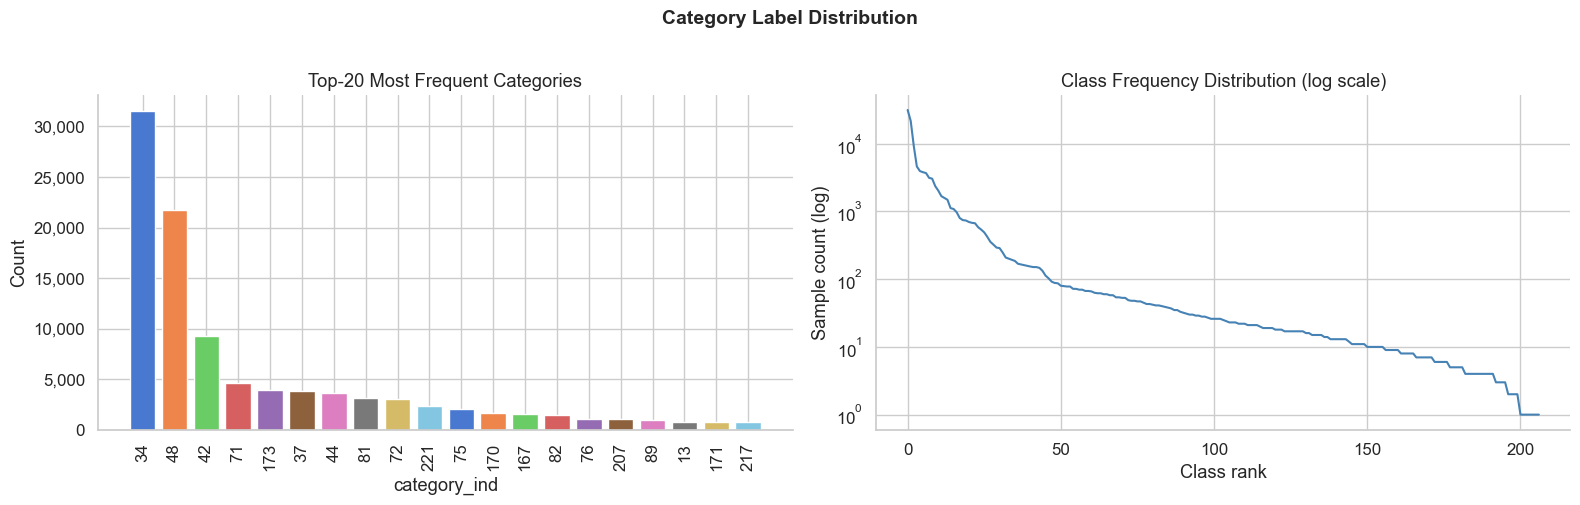

In [8]:
# ── 4b. Class distribution bar chart ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top-20 most frequent classes
top20 = vc.head(20)
axes[0].bar(top20.index.astype(str), top20.values, color=sns.color_palette('muted', 20))
axes[0].set_title('Top-20 Most Frequent Categories')
axes[0].set_xlabel('category_ind')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=90)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Log-scale full distribution
axes[1].plot(range(len(vc)), sorted(vc.values, reverse=True), color='steelblue')
axes[1].set_yscale('log')
axes[1].set_title('Class Frequency Distribution (log scale)')
axes[1].set_xlabel('Class rank')
axes[1].set_ylabel('Sample count (log)')

plt.suptitle('Category Label Distribution', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

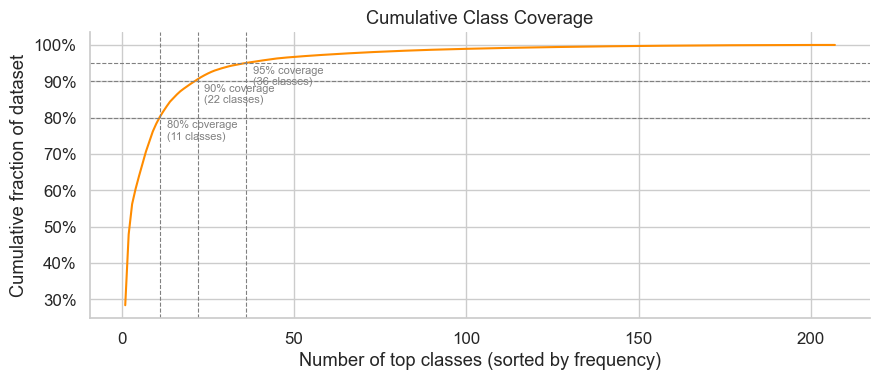

In [9]:
# ── 4c. Cumulative coverage: how many classes cover 80 / 90 / 95% of data ─────
cumsum = vc.cumsum() / len(y)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(cumsum)+1), cumsum.values, color='darkorange')
for threshold in [0.80, 0.90, 0.95]:
    idx = int((cumsum < threshold).sum()) + 1
    ax.axhline(threshold, linestyle='--', linewidth=0.8, color='grey')
    ax.axvline(idx, linestyle='--', linewidth=0.8, color='grey')
    ax.annotate(f'{int(threshold*100)}% coverage\n({idx} classes)',
                xy=(idx, threshold), xytext=(idx+2, threshold-0.06),
                fontsize=8, color='grey')

ax.set_title('Cumulative Class Coverage')
ax.set_xlabel('Number of top classes (sorted by frequency)')
ax.set_ylabel('Cumulative fraction of dataset')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

---
## 5. Text Feature Analysis

In [10]:
# ── 5a. Per-column: non-null rate & avg text length ───────────────────────────
available_text_cols = [c for c in TEXT_COLS if c in df.columns]

text_stats = []
for col in available_text_cols:
    series = df[col].fillna('').astype(str)
    non_empty = (series.str.strip() != '').sum()
    char_len  = series[series.str.strip() != ''].str.len()
    word_cnt  = series[series.str.strip() != ''].str.split().str.len()
    text_stats.append({
        'column':          col,
        'non_empty_rate':  f'{non_empty / len(df) * 100:.1f}%',
        'avg_char_len':    round(char_len.mean(), 1),
        'median_char_len': round(char_len.median(), 1),
        'avg_word_count':  round(word_cnt.mean(), 1),
    })

text_stats_df = pd.DataFrame(text_stats).set_index('column')
print('Text column statistics:')
display(text_stats_df)

Text column statistics:


,non_empty_rate,avg_char_len,median_char_len,avg_word_count
column,,,,
name,56.1%,31.3,24.0,4.6
description,35.2%,137.3,87.0,18.7
model,43.4%,21.3,16.0,3.4
type_prefix,17.2%,12.4,7.0,1.9
vendor,94.0%,11.2,10.0,1.6
url,100.0%,80.1,76.0,1.0


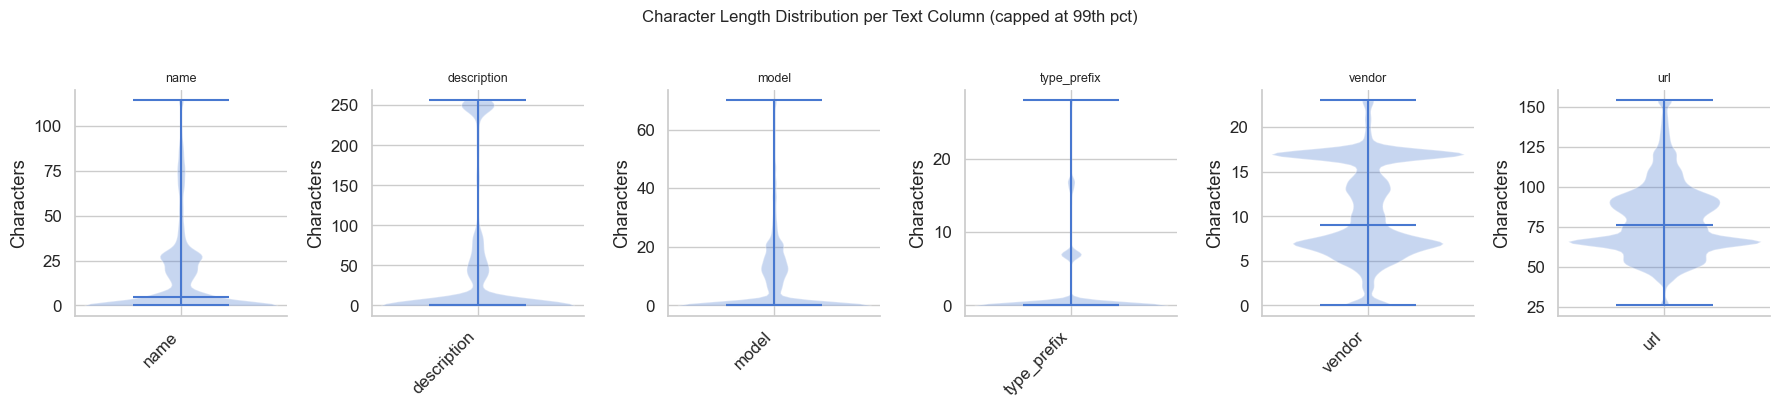

In [11]:
# ── 5b. Character-length violin plots ─────────────────────────────────────────
n_cols = len(available_text_cols)
fig, axes = plt.subplots(1, n_cols, figsize=(3*n_cols, 4), sharey=False)

if n_cols == 1:
    axes = [axes]

for ax, col in zip(axes, available_text_cols):
    lengths = df[col].fillna('').astype(str).str.len()
    # Cap extreme outliers for readability
    cap = lengths.quantile(0.99)
    lengths_capped = lengths.clip(upper=cap)
    ax.violinplot(lengths_capped, positions=[0], showmedians=True)
    ax.set_xticks([0])
    ax.set_xticklabels([col], rotation=45, ha='right')
    ax.set_ylabel('Characters')
    ax.set_title(col, fontsize=9)

plt.suptitle('Character Length Distribution per Text Column (capped at 99th pct)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

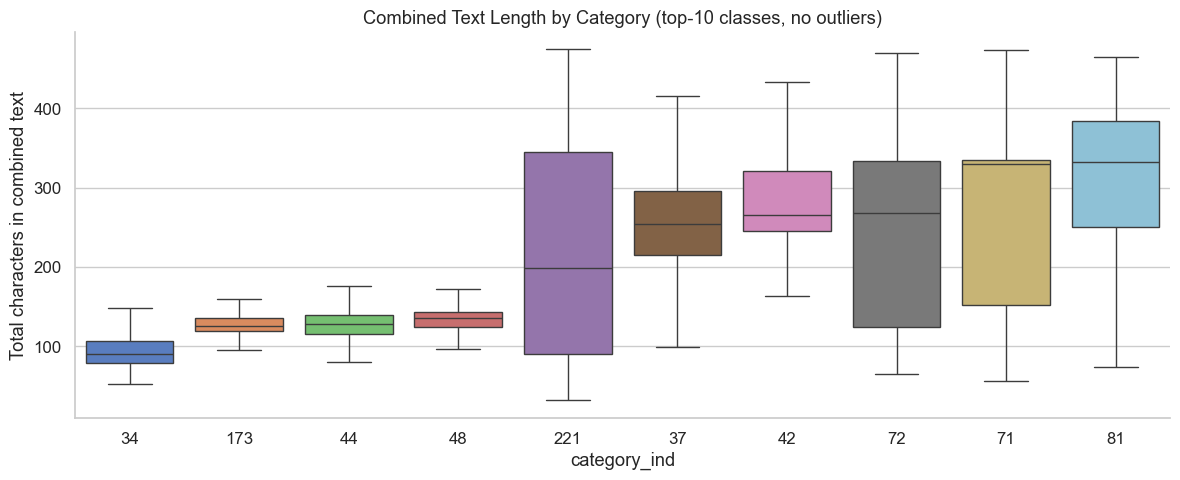

In [12]:
# ── 5c. Combined text length vs category (top 10 classes) ────────────────────
combined = pd.concat(
    [df[c].fillna('').astype(str) for c in available_text_cols],
    axis=1
).apply(lambda row: ' '.join(row), axis=1)

df['combined_len'] = combined.str.len()

top10_classes = vc.head(10).index.tolist()
sub = df[df[TARGET_COL].isin(top10_classes)][['combined_len', TARGET_COL]]

fig, ax = plt.subplots(figsize=(12, 5))
order = sub.groupby(TARGET_COL)['combined_len'].median().sort_values().index
sns.boxplot(
    data=sub, x=TARGET_COL, y='combined_len',
    order=order, palette='muted', ax=ax,
    showfliers=False,
)
ax.set_title('Combined Text Length by Category (top-10 classes, no outliers)')
ax.set_xlabel('category_ind')
ax.set_ylabel('Total characters in combined text')
plt.tight_layout()
plt.show()

---
## 6. Numerical Feature Distributions

In [14]:
# ── 6a. Histograms of all numeric columns (excluding target) ──────────────────
num_cols = [
    c for c in df.select_dtypes(include='number').columns
    if c not in [TARGET_COL, 'combined_len']
]

if num_cols:
    n_plots = len(num_cols)
    ncols   = min(4, n_plots)
    nrows   = (n_plots + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten() if n_plots > 1 else [axes]

    for ax, col in zip(axes, num_cols):
        col_data = df[col].dropna()
        # Cap at 1st–99th percentile for cleaner plots
        lo, hi = col_data.quantile([0.01, 0.99])
        col_data = col_data.clip(lo, hi)
        ax.hist(col_data, bins=40, color='steelblue', alpha=0.8, edgecolor='white')
        ax.set_title(col, fontsize=10)
        ax.set_xlabel('Value')
        ax.set_ylabel('Count')

    # Hide unused axes
    for ax in axes[n_plots:]:
        ax.set_visible(False)

    plt.suptitle('Numeric Feature Distributions (clipped 1%–99%)', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('No additional numeric columns (apart from target) found.')

No additional numeric columns (apart from target) found.


---
## 7. Correlation Analysis

In [15]:
# ── 7a. Numeric correlation heatmap ───────────────────────────────────────────
corr_cols = [c for c in df.select_dtypes(include='number').columns
             if c != 'combined_len']

if len(corr_cols) >= 2:
    corr = df[corr_cols].corr(method='pearson')
    mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask

    fig, ax = plt.subplots(figsize=(min(12, 1.2*len(corr_cols)),
                                     min(10, 1.1*len(corr_cols))))
    sns.heatmap(
        corr, mask=mask,
        annot=True, fmt='.2f', cmap='coolwarm',
        center=0, vmin=-1, vmax=1,
        square=True, linewidths=0.5, ax=ax,
    )
    ax.set_title('Pearson Correlation — Numeric Features', fontsize=13)
    plt.tight_layout()
    plt.show()

    # Strongest correlations with target
    if TARGET_COL in corr.columns:
        target_corr = corr[TARGET_COL].drop(TARGET_COL).sort_values(key=abs, ascending=False)
        print('\nCorrelation with target (category_ind):')
        print(target_corr.to_string())
else:
    print('Insufficient numeric columns for correlation analysis.')

Insufficient numeric columns for correlation analysis.


---
## 8. Class Imbalance Assessment

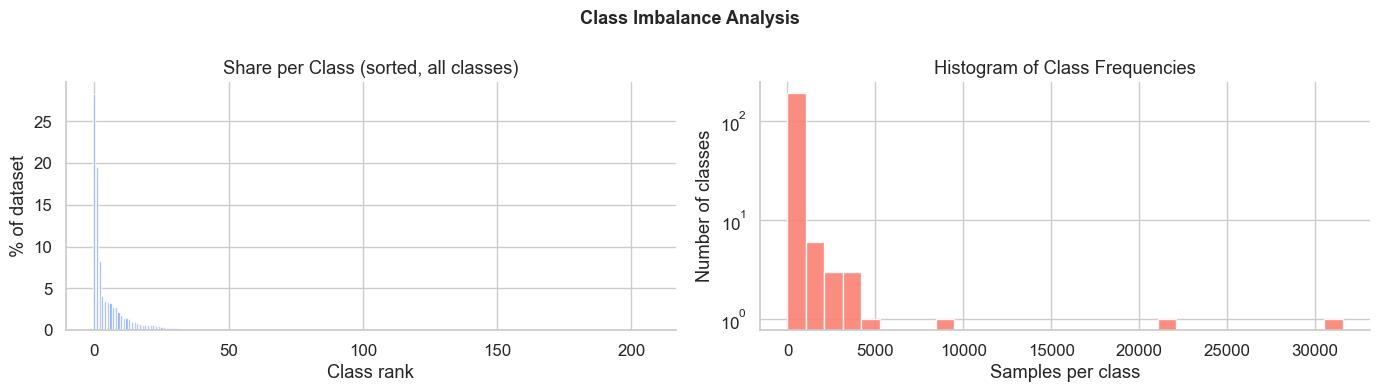

Classes with < 10 samples  : 51
Classes with < 50 samples  : 135
Classes with < 100 samples : 160


In [16]:
# ── 8a. Class imbalance summary ───────────────────────────────────────────────
vc_pct = (vc / len(y) * 100).round(3)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Pareto chart: sorted class share
axes[0].bar(range(len(vc_pct)), vc_pct.values, color='cornflowerblue', alpha=0.8)
axes[0].set_title('Share per Class (sorted, all classes)')
axes[0].set_xlabel('Class rank')
axes[0].set_ylabel('% of dataset')

# Histogram of class frequencies
axes[1].hist(vc.values, bins=30, color='salmon', edgecolor='white', alpha=0.9)
axes[1].set_title('Histogram of Class Frequencies')
axes[1].set_xlabel('Samples per class')
axes[1].set_ylabel('Number of classes')
axes[1].set_yscale('log')

plt.suptitle('Class Imbalance Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Classes with < 10 samples  : {(vc <  10).sum()}")
print(f"Classes with < 50 samples  : {(vc <  50).sum()}")
print(f"Classes with < 100 samples : {(vc < 100).sum()}")

---
## 9. Key Findings & Recommendations

After exploring the dataset, here is a structured summary of the most important observations and their implications for the MLOps pipeline:

### 9.1 Dataset Profile
- **Source:** E-commerce product catalogue collected for the Kaggle competition *Production ML Spring 2026*.
- **Task:** Multi-class text classification — predict `category_ind` from product text metadata.
- **Features used:** `name`, `description`, `model`, `type_prefix`, `vendor`, `url` — all free-text strings.

### 9.2 Missing Values
- Several text columns (`description`, `model`, `type_prefix`) contain missing values.
- **Action taken in `preprocess.py`:** fill NaN with empty string before concatenation — this is safe because TF-IDF simply contributes no tokens from empty fields.

### 9.3 Target / Class Distribution
- The dataset exhibits **strong class imbalance**: a handful of frequent categories dominate while many tail classes have very few samples.
- The log-scale distribution plot reveals a Zipf-like pattern — common in real e-commerce catalogues.
- **MLOps implication:** macro-F1 is the primary metric (not accuracy) to avoid the model simply memorising the head classes.

### 9.4 Text Features
- `name` and `description` carry the most information (highest non-empty rates and meaningful lengths).
- `url` is useful for domain disambiguation but noisy; TF-IDF bigrams should capture most of its signal.
- Combined text length varies significantly across categories — longer descriptions correlate with electronics/tech categories.

### 9.5 Model Choice Justification
| Model | Rationale |
|---|---|
| **TF-IDF + LogisticRegression** | Proven strong baseline for sparse text; fast to train; interpretable weights; well-supported in scikit-learn |
| Bigram range `(1, 2)` | Captures product phrases like *"noise cancelling"* or *"wireless charging"* which unigrams miss |
| `sublinear_tf=True` | Reduces the effect of very frequent words; improves performance on long-tail classes |
| `saga` solver | Efficient for large, sparse multi-class problems |

### 9.6 MLOps Recommendations
1. **Data versioning:** Use DVC or MLflow dataset tracking to pin the parquet version used in each experiment.
2. **Monitoring:** Track `val_f1_macro` across runs; alert if it drops below 0.70 in production.
3. **Retraining trigger:** Schedule retraining when new product categories appear or when the tail class F1 drops.
4. **Experiment tracking:** Three MLflow runs with different `C` and `max_features` are already in `train.py`; compare in the MLflow UI at `http://localhost:5000`.
5. **Future improvements:** Consider fine-tuning a sentence-transformer (e.g., `paraphrase-multilingual-MiniLM-L12-v2`) for richer embeddings.

In [17]:
# ── Final: quick prototype — TF-IDF + LR inline sanity check ─────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.pipeline import Pipeline

# Build combined text feature
X_text = pd.concat(
    [df[c].fillna('').astype(str) for c in available_text_cols], axis=1
).apply(lambda row: ' '.join(row), axis=1)

y_labels = df[TARGET_COL].astype(int)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_text, y_labels, test_size=0.2, random_state=42,
    stratify=(y_labels if y_labels.value_counts().min() >= 2 else None)
)

pipe = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=100_000,
                               min_df=2, sublinear_tf=True)),
    ('clf',   LogisticRegression(C=1.0, max_iter=500, solver='saga',
                                  n_jobs=-1, random_state=42))
])

print('Fitting prototype model …')
pipe.fit(X_tr, y_tr)

y_pred = pipe.predict(X_val)
acc  = accuracy_score(y_val, y_pred)
f1   = f1_score(y_val, y_pred, average='macro', zero_division=0)

print(f'\n✅  Prototype validation results:')
print(f'   Accuracy (val) : {acc:.4f}')
print(f'   F1-macro (val) : {f1:.4f}')
print('\nFor full tracked experiments run: python src/train.py')

Fitting prototype model …

✅  Prototype validation results:
   Accuracy (val) : 0.9614
   F1-macro (val) : 0.3608

For full tracked experiments run: python src/train.py
